# Lektion 4 - Data Vizualization

## 1) Load the ECG data set

Første opgave består af at indlæse et datasæt som består af EKG optagelser af 28 professionelle atleter. For at kunne indlæse datasættet, er der brugt biblioteket `WFDB` (Waveform Database). Metoden `rdsamp` bruges til at indlæse data filer så vi kan bearbejde dem igennem vores python miljø, metoden retunere 2 variabler, `signals` som er de fysiologiske signaler der er optaget, og `fields` som er en samling af forskellige atributter i datasættet. Dette inkludere:
- fs - Målings frekvensen
- units - Enhederne målet, for hver kanal
- sig_name - Signal navnet for hver kanal
- comments - eventuelle kommentare

In [1]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
import os

directory = "./norwegian-endurance-athlete-ecg-database-1.0.0/"
ECGs = []
for ecgfilename in sorted(os.listdir(directory)):
    if ecgfilename.endswith(".dat"):
        record_path = os.path.join(directory, ecgfilename[:-4]) # remove ".dat"
        signal, fields = wfdb.rdsamp(record_path)
        ECGs.append(signal)

ECGs = np.array(ECGs, dtype=object)
fs = 500

## 2) Plot ECG leads 1-12 for one person as subplots in one figure.

For at kunne udskrive en figur der viser alle 12 leads signaler, er der valgt at lave en forlykke som ittere 12 gange. Hver itteration henter den føreste persons lead og plotter det som en subfigur. Efter 6 leads er printet laves der en ny kolonne, dette resultere i en figur med 12 subplots, 2 kolonner med 6 plots i hver kolonne. 

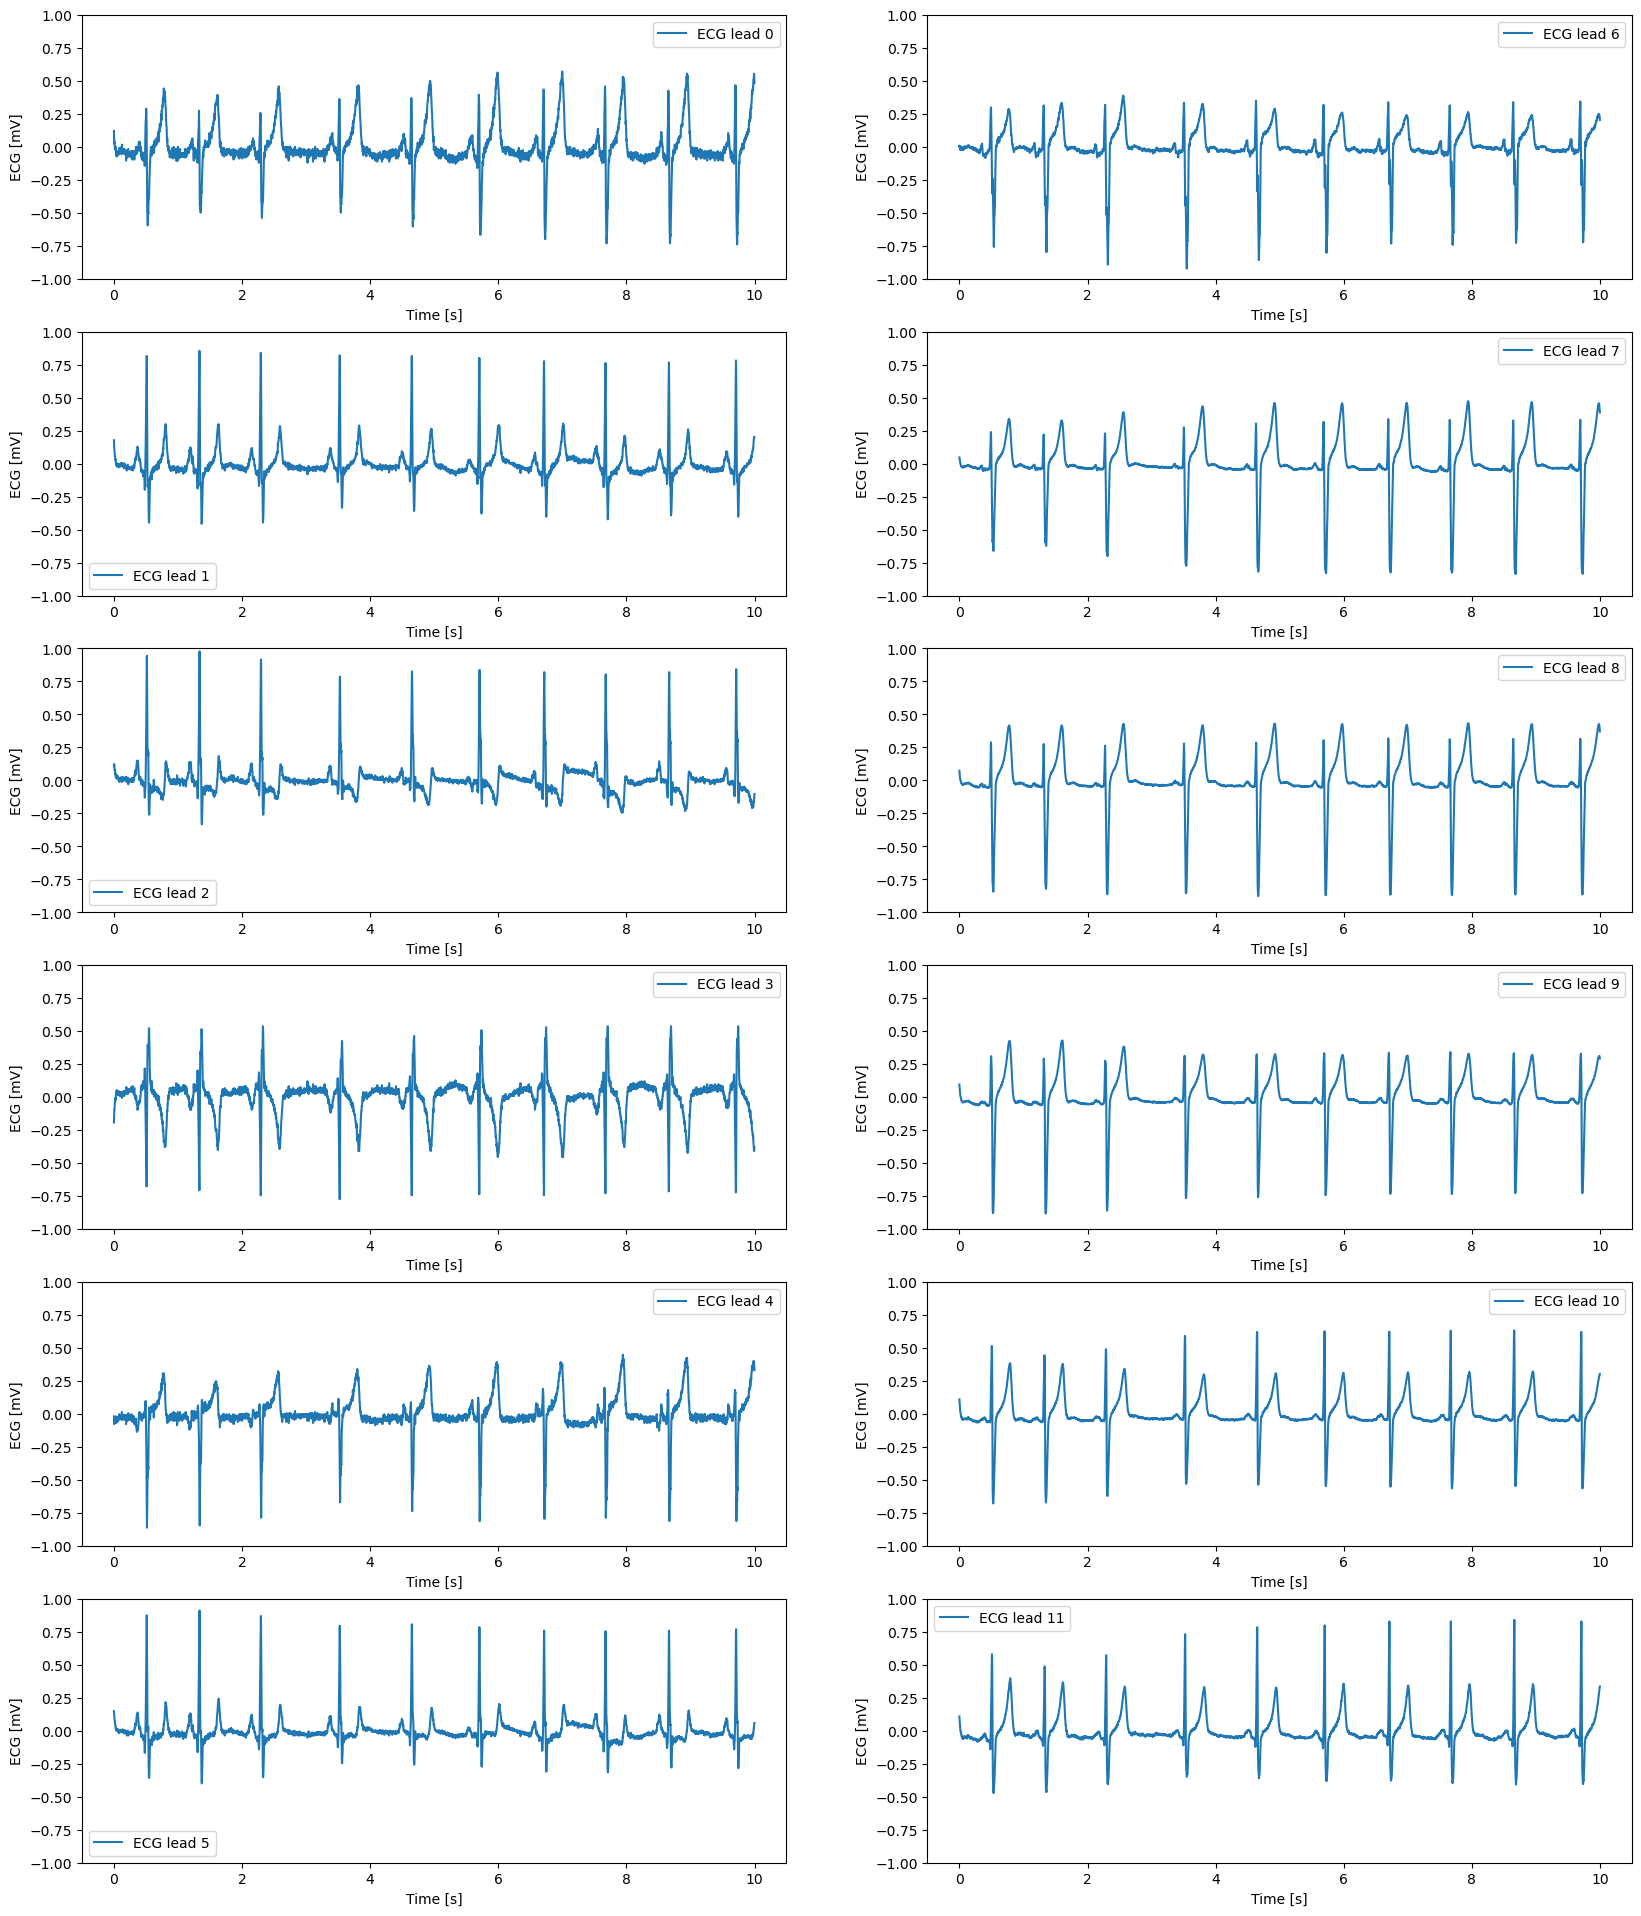

In [2]:
fig, axs = plt.subplots(6,2, figsize=(20,24))
column = 0
row = 0

for lead in range(0,12):
    ecg = ECGs[0,:,lead]
    time = np.arange(len(ecg))/fs
    ecg = np.asarray(ecg, dtype=float)
    ecg = ecg-np.mean(ecg)

    axs[row,column].plot(time,ecg, label = f"ECG lead {lead}")
    axs[row,column].set_ylim(-1, 1)
    axs[row,column].legend()
    axs[row,column].set_xlabel("Time [s]")
    axs[row,column].set_ylabel("ECG [mV]")

    row += 1
    if lead == 5:
        column += 1
        row = 0


plt.show()

## 3) Plot ECG lead 2 for 12 (or all 28) persons as subplots in one figure.

For at kunne printe alle 28 personers data for lead 2 bruges der samme forlykke, denne gang med 28 itterationer, og i stædet for at bruge hver itteration til at printe leads data, bruges det til at printe alle personernes data for lead 2

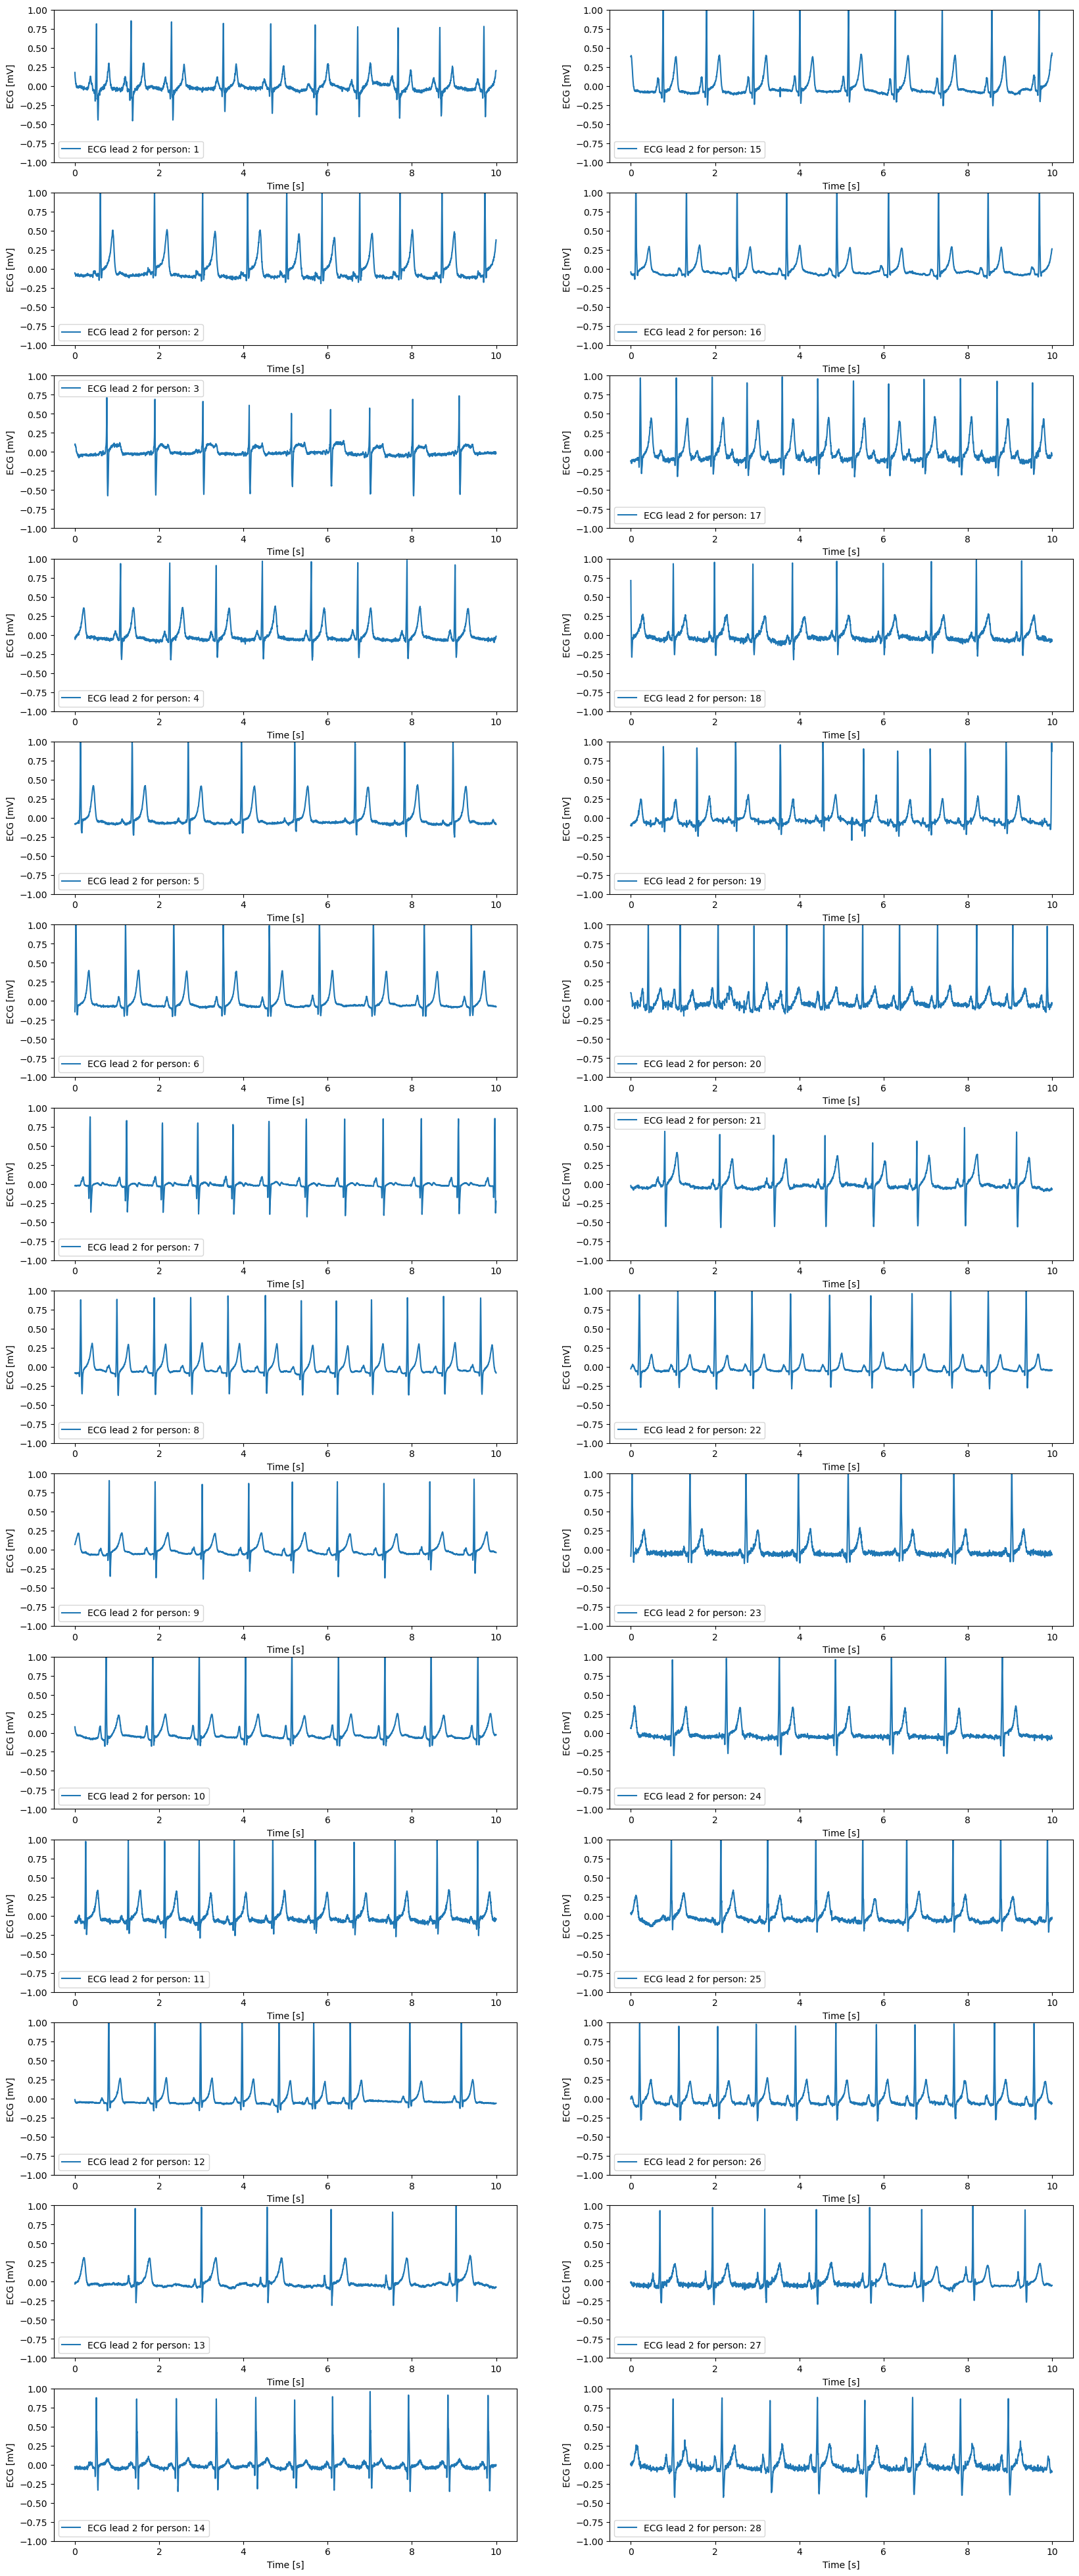

In [3]:
fig, axs = plt.subplots(14,2, figsize=(20,50))
column = 0
row = 0

for person in range(0,28):
    ecg = ECGs[person,:,1]
    time = np.arange(len(ecg))/fs
    ecg = np.asarray(ecg, dtype=float)
    ecg = ecg-np.mean(ecg)

    axs[row,column].plot(time,ecg, label = f"ECG lead 2 for person: {person+1}")
    axs[row,column].set_ylim(-1, 1)
    axs[row,column].legend()
    axs[row,column].set_xlabel("Time [s]")
    axs[row,column].set_ylabel("ECG [mV]")

    row += 1
    if person == 13:
        column += 1
        row = 0

plt.show()

## 4) For all 28 persons, calculate periodograms for ECG lead 2 and plot them as a colormap

For at kunne lave et pariodogram som et "colormap", udregnes der en forier transformationen til dataen i den valgte lead. Dette gøres i en forlykke der køres igennem 28 gange, hvor hver itteration udregner den en forier transformation til en ny persons data, sidst i lykken bliver denne transformation gemt i listen `powers`.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

n_people = 28 # Antal atleter vi vil plotte
n_samples = 2501 # Antal samples i datasets
freq = np.linspace(0, fs/2, n_samples) # Frekvens akse

#Beregn Power Spectral Density for alle atleter. Saml i en lists.
powers = []
for person in range(0,n_people):
    ecg = ECGs[person,:,1]
    ecg = np.asarray(ecg, dtype=float)
    fft=np.fft.rfft(ecg)
    fft_abs=abs(fft)
    psd = (fft_abs**2)/(len(ecg)*fs)
    powers.append(psd)

#Formater så psd for hver atlet svarer til en kolonne
power_matrix = np.column_stack(powers)

For at kunne vise power spektret som et colormap, bruges `pcolormesh` til at plotte. Først laves akserne ved hjælp af `meshgrid`, hvor x-aksen er de 28 atleter og y-aksen er frekvenserne fra 0 til Nyquist frekvensen. Med `vmin` og `vmax` sættes farveskalaen til at passe til værdierne i datasættet.

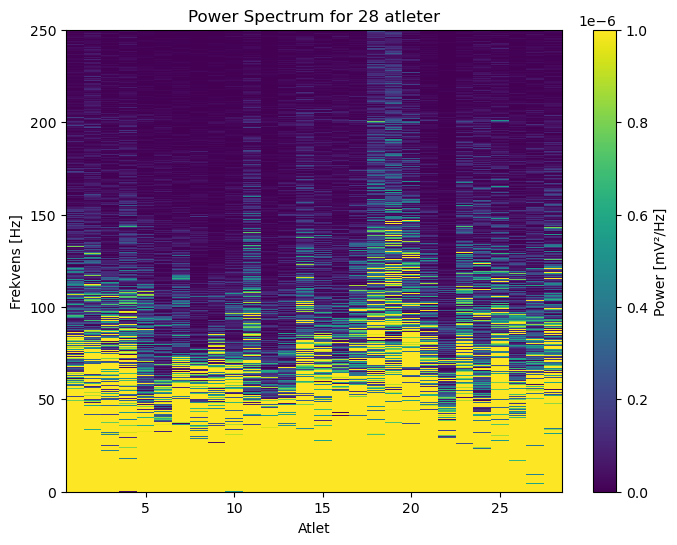

In [5]:
people = np.arange(1, n_people + 1) # Til X-akse
X, Y = np.meshgrid(people, freq) # Til color mesh

plt.figure(figsize=(8, 6))
pcm = plt.pcolormesh(X, Y, power_matrix,
                     shading='auto',
                     vmin=0, vmax=0.000001)

plt.xlabel("Atlet")
plt.ylabel("Frekvens [Hz]")
plt.ylim(0,fs/2)
plt.title(f"Power Spectrum for {n_people} atleter")

plt.colorbar(pcm, label="Power [mV²/Hz]")

plt.show()

Herefter ændre vi skaløren til at følge $log_{10}$ 

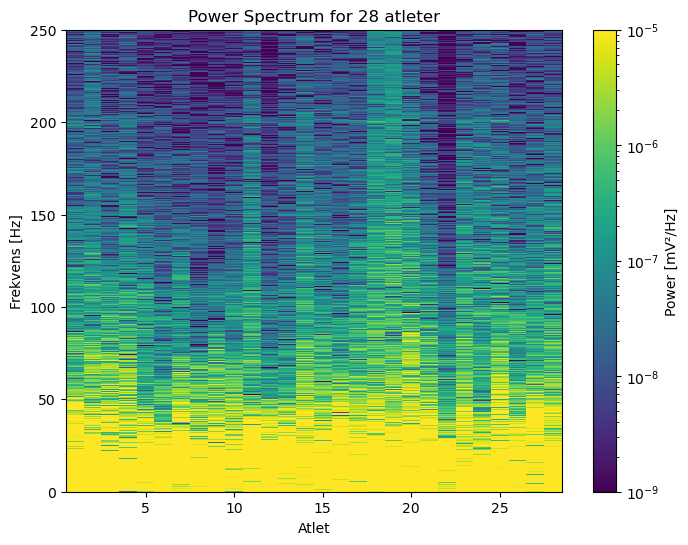

In [6]:
plt.figure(figsize=(8, 6))
from matplotlib.colors import LogNorm

pcm = plt.pcolormesh(X, Y, power_matrix,
                     shading='auto',
                     norm=LogNorm(vmin=1e-9, vmax=1e-5))

plt.xlabel("Atlet")
plt.ylabel("Frekvens [Hz]")
plt.ylim(0,fs/2)
plt.title(f"Power Spectrum for {n_people} atleter")

plt.colorbar(pcm, label="Power [mV²/Hz]")

plt.show()